# Task-variance clustering

Analysis pipeline from [Yang et al. 2019](https://www.nature.com/articles/s41593-018-0310-2) (Fig. 2):

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import ortho_group
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from task import generate_trials
from train_cog import load_checkpoint, trial_to_tensors

plt.style.use("dark_background")

CHECKPOINT_PATH = "checkpoints/dale_20_50000_2026-09-03_14-06-22.pt"
# CHECKPOINT_PATH = "checkpoints/yang_20_50000_2026-09-03_14-59-10.pt"
N_PASSES = 10          # forward passes per task (new stimulus batch each pass)
BATCH_SIZE = 512       # trials per pass — spans stimulus / coherence space

K_RANGE = range(12,30)   # cluster counts to scan
ACTIVE_THRESH = 1e-3     # drop near-silent units


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, config, checkpoint = load_checkpoint(CHECKPOINT_PATH, device=device, eval_mode=True)
rules = list(checkpoint["active_tasks"])
history = checkpoint.get("history")
model_type = checkpoint["model_type"]
n_units = model.n_rnn

# Dale: cluster excitatory units only (readout pool). Yang: all units.
if model_type == "dale":
    if not hasattr(model, "n_e"):
        raise ValueError(f"Expected DaleRNN with n_e, got {type(model).__name__}")
    cluster_unit_indices = np.arange(model.n_e)
    print(
        f"model_type={model_type}  n_units={n_units}  "
        f"(clustering: {model.n_e} E, {model.n_i} I excluded)"
    )
else:
    cluster_unit_indices = np.arange(n_units)
    print(f"model_type={model_type}  n_units={n_units}  (clustering: all units)")

print(f"tasks ({len(rules)}): {rules}")
if history is not None:
    print(f"train_steps={checkpoint.get('train_steps')}  final_loss={history['loss'][-1]:.4f}")


DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- C:\Users\athar\Documents\Github\canonical_mc\checkpoints\dale_20_50000_2026-09-03_14-06-22.pt  model=dale  tasks=['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']
model_type=dale  n_units=256  (clustering: 204 E, 52 I excluded)
tasks (20): ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']
train_steps=50000  final_loss=0.0012


In [3]:
checkpoint['config']

{'dt': 20,
 'tau': 100.0,
 'alpha': 0.2,
 'sigma_x': 0.01,
 'n_eachring': 16,
 'n_neurons_per_ring': 16,
 'num_ring': 2,
 'n_rule': 20,
 'n_rules': 20,
 'ruleset': 'all',
 'rule_start': 33,
 'n_input': 53,
 'n_output': 17,
 'loss_type': 'lsq',
 'easy_task': True}

In [4]:
# checkpoints check for sparsity i.e. connection regularizer
checkpoint['model_kwargs']

{'n_neurons': 256, 'frac_e': 0.8, 'g': 1.0, 'sigma_rec': 0.05, 'seed': 0}

## Task variance — stimulus sampling

Following Yang et al., task variance $\mathrm{TV}_i(A)$ for unit $i$ and task $A$ requires running the trained network on **many stimulus conditions** that span the task's input space. Here we use **`N_PASSES` forward passes per task**, each with a fresh random batch of **`BATCH_SIZE` trials** (noise-free), then average the per-pass task variance.


In [5]:
def run_passes_for_task(model, config, rule, n_passes, batch_size, device):
    """Run ``n_passes`` noise-free simulations for one task.

    Each pass draws a fresh batch of trials (new stimulus locations,
    coherences, timings, etc.). Returns a list of post-fixation activity
    arrays, each with shape (T, batch_size, N).
    """
    model.eval()
    chunks = []
    with torch.no_grad():
        for p in range(n_passes):
            trial = generate_trials(rule, config, batch_size, noise_on=False)
            x, _, _, _ = trial_to_tensors(trial, device)
            r_hist, _, _ = model.simulate(x, noise_level=0.0)
            t_start = trial.epochs["fix1"][1]
            h = r_hist[:, t_start:, :].permute(1, 0, 2).cpu().numpy()  # (T, B, N)
            chunks.append(h)
            if p == 0:
                print(f"  {rule}: pass 1 — T={h.shape[0]}, batch={h.shape[1]}", end="")
            elif p == n_passes - 1:
                print(f" ... pass {n_passes} — T={h.shape[0]}")
    return chunks


def task_variance_from_activity(h):
    """Yang task variance: var across conditions at each t, mean over time."""
    return h.var(axis=1).mean(axis=0)


def task_variance_from_passes(chunks):
    """Average task variance across passes (each pass = one stimulus batch)."""
    return np.mean([task_variance_from_activity(h) for h in chunks], axis=0)


def pool_passes_for_storage(chunks):
    """Concatenate passes along batch; pad time to max T with edge values."""
    t_max = max(h.shape[0] for h in chunks)
    padded = []
    for h in chunks:
        if h.shape[0] < t_max:
            pad = t_max - h.shape[0]
            h = np.pad(h, ((0, pad), (0, 0), (0, 0)), mode="edge")
        padded.append(h)
    return np.concatenate(padded, axis=1)


def collect_task_variance_multi_pass(model, config, rules, n_passes, batch_size, device):
    """TV_i(A) for all units and tasks using many stimulus conditions."""
    n_units = model.n_rnn
    h_var_all = np.zeros((n_units, len(rules)), dtype=np.float64)
    activity_by_rule = {}

    print(f"Running {n_passes} noise-free passes × batch {batch_size} per task ({len(rules)} tasks)...")
    for i, rule in enumerate(rules):
        chunks = run_passes_for_task(model, config, rule, n_passes, batch_size, device)
        activity_by_rule[rule] = pool_passes_for_storage(chunks)
        h_var_all[:, i] = task_variance_from_passes(chunks)
        n_conditions = n_passes * batch_size
        print(f"    -> {n_conditions} conditions, mean TV={h_var_all[:, i].mean():.4f}")

    return h_var_all, activity_by_rule


h_var_all, activity_by_rule = collect_task_variance_multi_pass(
    model, config, rules, N_PASSES, BATCH_SIZE, device
)
print(f"h_var_all shape: {h_var_all.shape}  (units × tasks)")
print(f"conditions per task: {N_PASSES} passes × {BATCH_SIZE} batch = {N_PASSES * BATCH_SIZE}")

Running 10 noise-free passes × batch 512 per task (20 tasks)...
  fdgo: pass 1 — T=84, batch=512 ... pass 10 — T=95
    -> 5120 conditions, mean TV=0.1246
  reactgo: pass 1 — T=25, batch=512 ... pass 10 — T=25
    -> 5120 conditions, mean TV=0.0919
  delaygo: pass 1 — T=45, batch=512 ... pass 10 — T=95
    -> 5120 conditions, mean TV=0.1297
  fdanti: pass 1 — T=86, batch=512 ... pass 10 — T=80
    -> 5120 conditions, mean TV=0.1696
  reactanti: pass 1 — T=25, batch=512 ... pass 10 — T=25
    -> 5120 conditions, mean TV=0.0908
  delayanti: pass 1 — T=125, batch=512 ... pass 10 — T=65
    -> 5120 conditions, mean TV=0.1633
  dm1: pass 1 — T=65, batch=512 ... pass 10 — T=105
    -> 5120 conditions, mean TV=0.1852
  dm2: pass 1 — T=105, batch=512 ... pass 10 — T=65
    -> 5120 conditions, mean TV=0.1888
  contextdm1: pass 1 — T=65, batch=512 ... pass 10 — T=65
    -> 5120 conditions, mean TV=0.3420
  contextdm2: pass 1 — T=65, batch=512 ... pass 10 — T=45
    -> 5120 conditions, mean TV=0.

## KMeans clustering on task-variance profiles

Max-normalize each unit's task-variance vector, cluster units with k-means (scikit-learn), and pick $k$ that maximizes the silhouette score (Yang et al. Fig. 2).

For **Dale** checkpoints, clustering is restricted to **excitatory units only** (the readout pool). **Yang** checkpoints cluster all recurrent units.


In [13]:
# --- restrict unit pool (Dale: E-only; Yang: all) then filter active units ---
h_var_pool = h_var_all[cluster_unit_indices]
ind_active_local = np.where(h_var_pool.sum(axis=1) > ACTIVE_THRESH)[0]
h_var = h_var_pool[ind_active_local]
peak = h_var.max(axis=1, keepdims=True)
h_norm = h_var / np.where(peak > 0, peak, 1.0)   # (n_active, n_tasks)

# --- KMeans sweep + silhouette ---
k_list = [k for k in K_RANGE if k < h_norm.shape[0]]
scores, labels_list = [], []
for k in k_list:
    labels_k = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(h_norm)
    scores.append(silhouette_score(h_norm, labels_k))
    labels_list.append(labels_k)
scores = np.array(scores)
best_i = int(np.argmax(scores))
k_best = k_list[best_i]
labels = labels_list[best_i].copy()
silhouette_best = scores[best_i]

# Sort cluster IDs by dominant task (repo convention)
unique_labels = np.unique(labels)
label_prefs = [int(np.argmax(h_norm[labels == lab].mean(axis=0))) for lab in unique_labels]
relabel = {old: new for new, old in enumerate(np.argsort(label_prefs))}
labels = np.array([relabel[lab] for lab in labels])

sort_idx = np.argsort(labels)
labels_sorted = labels[sort_idx]
h_norm_sorted = h_norm[sort_idx]          # (units, tasks)
h_imshow = h_norm_sorted.T                  # (tasks, units) for imshow

pool_label = "excitatory" if model_type == "dale" else "all"
print(f"cluster pool: {len(cluster_unit_indices)} {pool_label} units")
print(f"active units: {len(ind_active_local)} / {len(cluster_unit_indices)}")
print(f"best k = {k_best},  silhouette = {silhouette_best:.3f}")
for lab in range(k_best):
    n_in = (labels == lab).sum()
    dom = rules[int(np.argmax(h_norm[labels == lab].mean(axis=0)))]
    print(f"  cluster {lab}: n={n_in:4d}, dominant task = {dom}")

cluster pool: 204 excitatory units
active units: 204 / 204
best k = 14,  silhouette = 0.130
  cluster 0: n=   6, dominant task = fdanti
  cluster 1: n=   4, dominant task = contextdm1
  cluster 2: n=   8, dominant task = contextdm1
  cluster 3: n=  16, dominant task = contextdm1
  cluster 4: n=  11, dominant task = contextdm2
  cluster 5: n=  14, dominant task = contextdm2
  cluster 6: n=  17, dominant task = contextdm2
  cluster 7: n=  30, dominant task = multidm
  cluster 8: n=  26, dominant task = multidm
  cluster 9: n=  15, dominant task = dmsgo
  cluster 10: n=  13, dominant task = dmsgo
  cluster 11: n=  15, dominant task = dmsgo
  cluster 12: n=  12, dominant task = dmsgo
  cluster 13: n=  17, dominant task = dmcgo


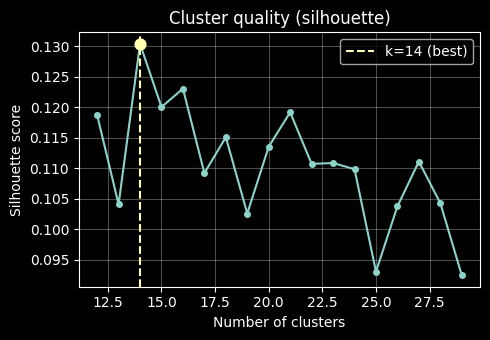

In [14]:
# Silhouette score vs number of clusters
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(k_list, scores, "o-", ms=4, color="C0")
ax.axvline(k_best, color="C1", ls="--", lw=1.5, label=f"k={k_best} (best)")
ax.scatter([k_best], [silhouette_best], color="C1", s=60, zorder=5)
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.set_title("Cluster quality (silhouette)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

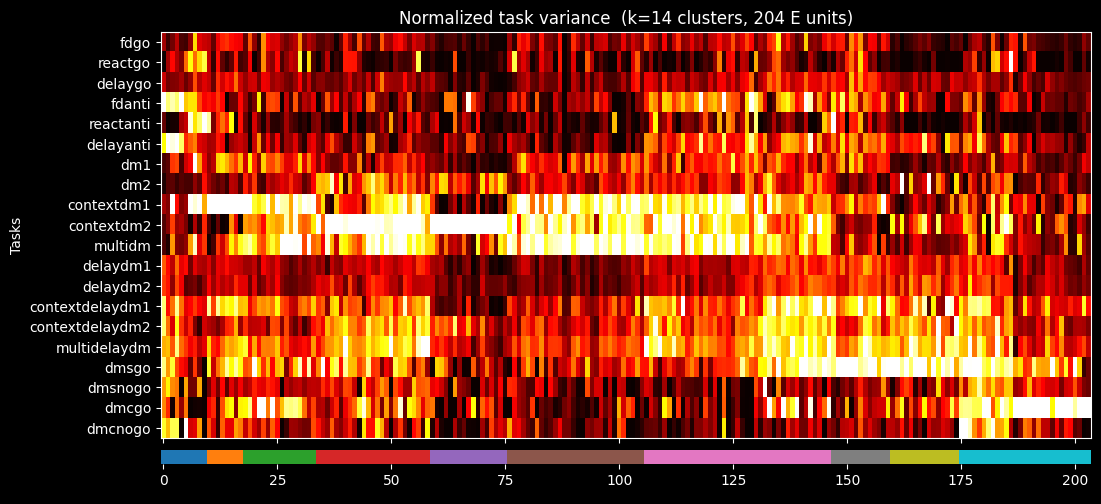

In [15]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

# Normalized task variance: tasks (y) × units (x), units sorted by cluster
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(3, 1, height_ratios=[20, 0.7, 0.9], hspace=0.08)
ax_main = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1], sharex=ax_main)
ax_counts = fig.add_subplot(gs[2], sharex=ax_main)

n_units_plot = h_imshow.shape[1]
im = ax_main.imshow(h_imshow, aspect="auto", cmap="hot", vmin=0, vmax=1, origin="upper")
ax_main.set_ylabel("Tasks")
ax_main.set_yticks(range(len(rules)))
ax_main.set_yticklabels(rules)
pool_title = f"{len(cluster_unit_indices)} E units" if model_type == "dale" else f"{len(cluster_unit_indices)} units"
ax_main.set_title(f"Normalized task variance  (k={k_best} clusters, {pool_title})")
ax_main.tick_params(axis="x", labelbottom=False)

# Cluster color strip (Yang Fig. 2 style)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, max(k_best, 1)))
ax_bar.set_xlim(-0.5, n_units_plot - 0.5)
ax_bar.set_ylim(0, 1)
ax_bar.set_yticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)

boundaries = np.concatenate([[0], np.where(np.diff(labels_sorted))[0] + 1, [n_units_plot]])
cluster_ids_in_order = [labels_sorted[s] for s in boundaries[:-1]]

for start, end, lab in zip(boundaries[:-1], boundaries[1:], cluster_ids_in_order):
    width = end - start
    ax_bar.add_patch(
        Rectangle(
            (start - 0.5, 0),
            width,
            1,
            facecolor=cluster_colors[lab],
            edgecolor="none",
        )
    )

# Unit counts centered under each cluster block
ax_counts.set_xlim(-0.5, n_units_plot - 0.5)
ax_counts.set_ylim(0, 1)
ax_counts.axis("off")
# for start, end, lab in zip(boundaries[:-1], boundaries[1:], cluster_ids_in_order):
#     n_in = end - start
#     center = (start + end - 1) / 2
#     ax_counts.text(
#         center,
#         0.55,
#         str(n_in),
#         ha="center",
#         va="center",
#         fontsize=9,
#         color=cluster_colors[lab],
#         fontweight="bold",
#     )
    # ax_counts.text(
    #     center,
    #     0.15,
    #     f"C{lab}",
    #     ha="center",
    #     va="center",
    #     fontsize=7,
    #     color="0.75",
    # )

ax_counts.set_xlabel("Units (sorted by cluster)")

# cbar = fig.colorbar(im, ax=ax_main, shrink=0.85, pad=0.02)
# cbar.set_label("Normalized task variance")

plt.show()

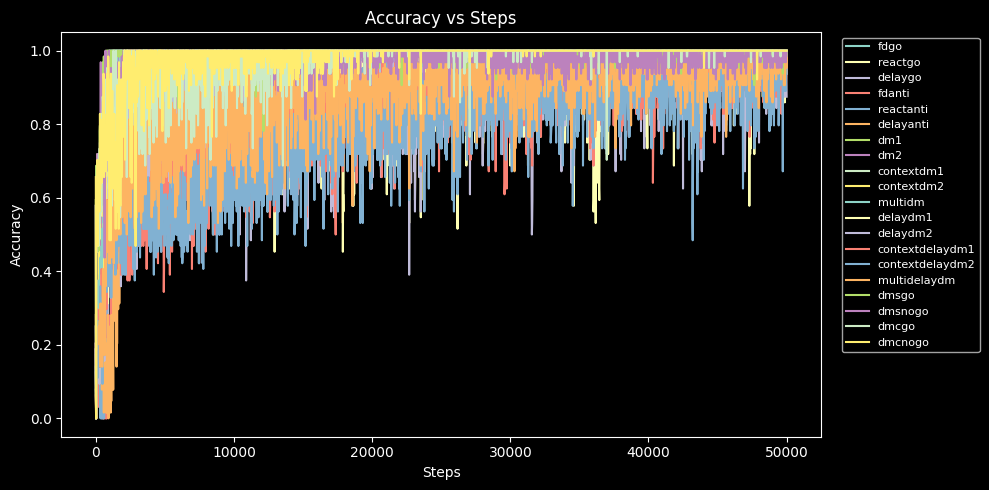

In [9]:
# Training recap: accuracy vs steps
if history is not None and "per_task" in history:
    plt.figure(figsize=(10, 5))
    for task in history["per_task"].keys():
        plt.plot(history["eval_step"], history["per_task"][task]["acc"], label=task)
    plt.xlabel("Steps")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Steps")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No training history in checkpoint.")